In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import scanpy as sc
import genes2genes as g2g
import warnings
warnings.filterwarnings("ignore")

from optbinning import ContinuousOptimalBinning

(CVXPY) Nov 12 10:04:36 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Nov 12 10:04:36 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


# 0. 导入数据

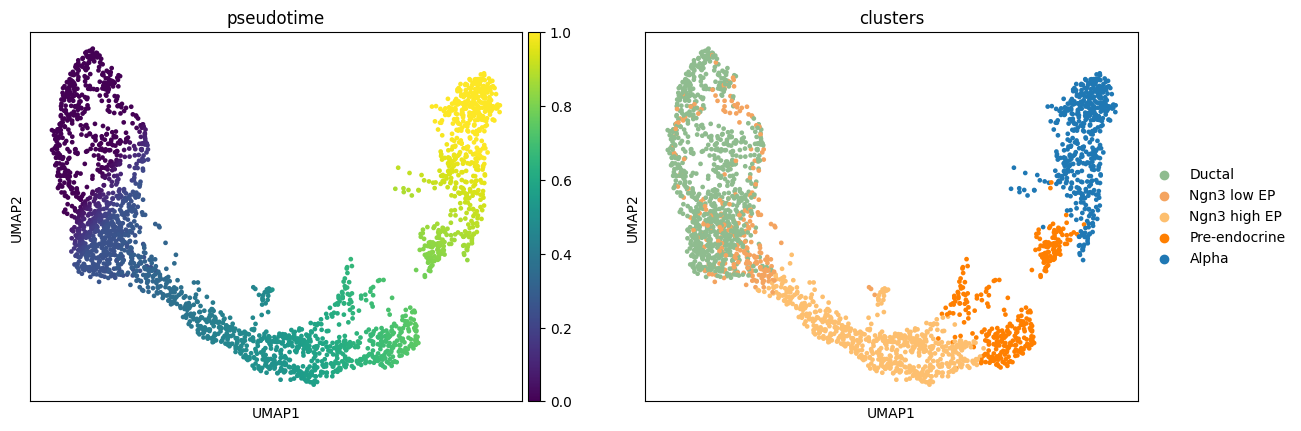

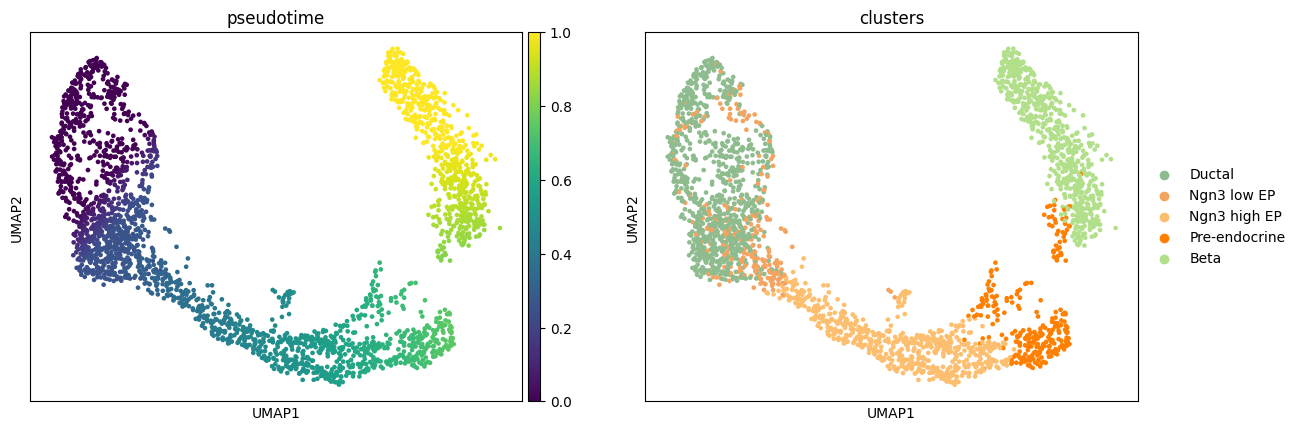

(AnnData object with n_obs × n_vars = 2623 × 2000
     obs: 'pseudotime', 'clusters', 'time'
     uns: 'clusters_colors', 'log1p'
     obsm: 'X_umap',
 AnnData object with n_obs × n_vars = 2674 × 2000
     obs: 'pseudotime', 'clusters', 'time'
     uns: 'clusters_colors', 'log1p'
     obsm: 'X_umap')

In [2]:
adata_ref = sc.read("./tmp/downstream_lineage_dev/pancreas-ref-lineage_to_Alpha.h5ad")
adata_query = sc.read("./tmp/downstream_lineage_dev/pancreas-ref-lineage_to_Beta.h5ad")
sc.pl.umap(adata_ref, color=["pseudotime", "clusters"])
sc.pl.umap(adata_query, color=["pseudotime", "clusters"])
adata_ref.obs["time"] = adata_ref.obs["pseudotime"]
adata_query.obs["time"] = adata_query.obs["pseudotime"]
adata_ref, adata_query

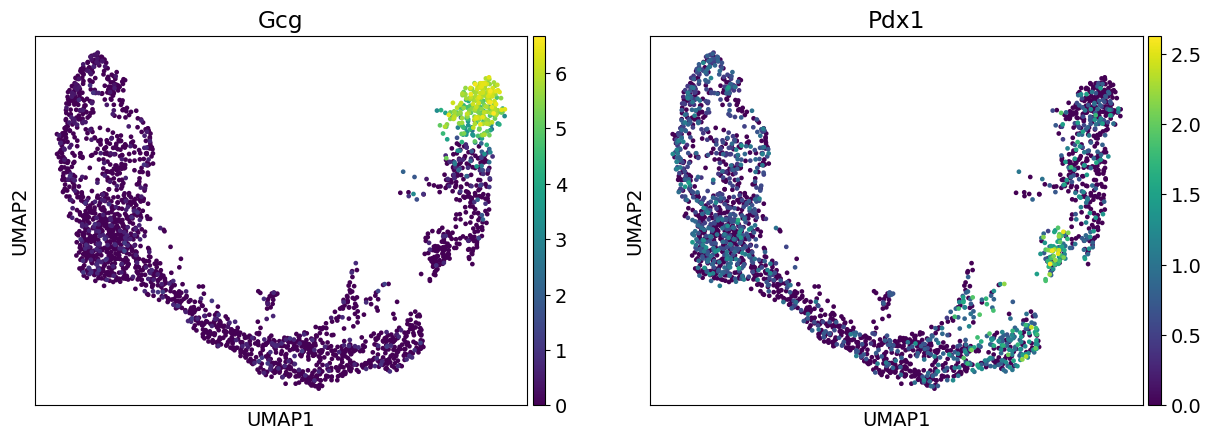

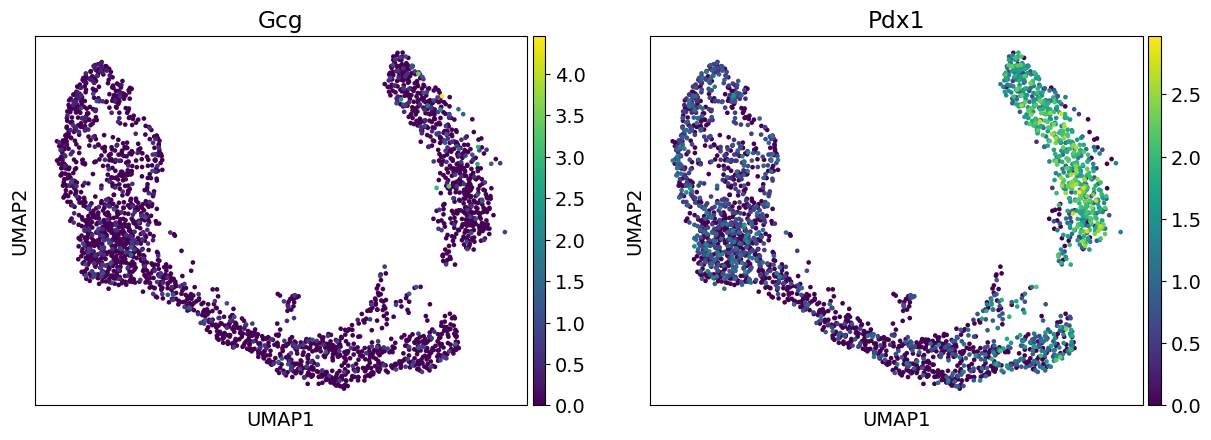

In [27]:
# marker基因查看
marker_gene_list = ["Gcg", "Pdx1"]
sc.pl.umap(adata_ref, color=marker_gene_list)
sc.pl.umap(adata_query, color=marker_gene_list)

## 1. 对齐准备

检查伪时间缩放到0-1

0.0 1.0
0.0 1.0


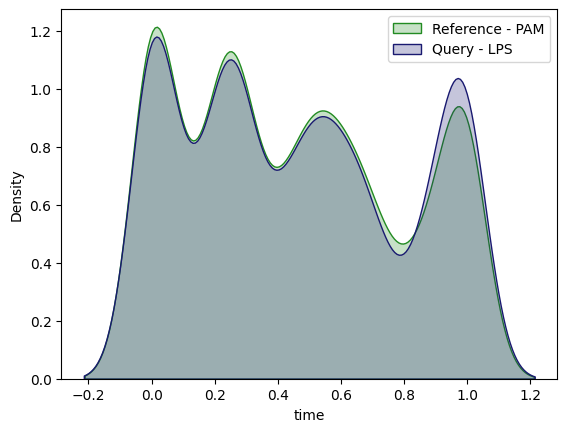

In [4]:
print(min(adata_ref.obs["time"]), max(adata_ref.obs["time"]))
print(min(adata_query.obs["time"]), max(adata_query.obs["time"]))

# Visualize the pseudotime distributions
sb.kdeplot(adata_ref.obs["time"], fill=True, label='Reference - PAM', color='forestgreen') 
sb.kdeplot(adata_query.obs["time"], fill=True, label='Query - LPS', color='midnightblue'); 
plt.xlabel('time'); plt.legend(); plt.show()

使用optbinning包来启发式地估计时间点的数量

In [5]:
x = np.asarray(adata_ref.obs["time"])
optb = ContinuousOptimalBinning(name="time", dtype="numerical")
optb.fit(x, x)
print(len(optb.splits))

x = np.asarray(adata_query.obs["time"])
optb = ContinuousOptimalBinning(name="time", dtype="numerical")
optb.fit(x, x)
print(len(optb.splits))

11
11


In [6]:
n_bins = 11

细胞类型注释和颜色模式

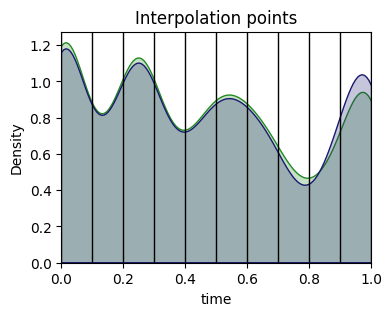

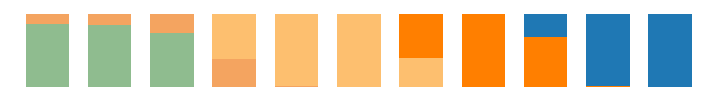

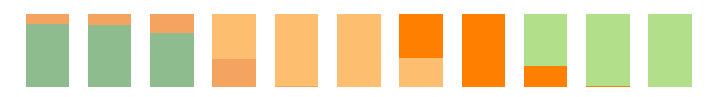

In [7]:
# define annotation column name in the adata obs
# 细胞index中包含了批次时间点
# annotation_colname = 'annotation'
# adata_ref.obs[annotation_colname] = [x.split('_')[1] for x in adata_ref.obs_names]
# adata_query.obs[annotation_colname] = [x.split('_')[1] for x in adata_query.obs_names]

# define the joint colormap to use for both reference and query
# col = np.array(sb.color_palette('colorblind'))[range(4)]
# joint_cmap={'1h':col[0], '2h':col[1] , '4h':col[2] , '6h':col[3]}

annotation_colname = "clusters"
joint_cmap = {
    "Ductal": "#8fbc8f",
    "Ngn3 low EP": "#f4a460",
    "Ngn3 high EP": "#fdbf6f",
    "Pre-endocrine": "#ff7f00",
    "Beta": "#b2df8a",
    "Alpha": "#1f78b4",
    "Delta": "#6a3d9a",
    "Epsilon": "#cab2d6"
}
g2g.VisualUtils.plot_pseudotime_dists_with_interpolation_points(adata_ref, adata_query, n_bins)
g2g.VisualUtils.plot_celltype_barplot(adata_ref, n_bins, annotation_colname, joint_cmap)
g2g.VisualUtils.plot_celltype_barplot(adata_query, n_bins, annotation_colname, joint_cmap)

## 2. G2G轨迹对齐

In [8]:
# define the gene list to align
gene_list = adata_ref.var_names 
print(len(gene_list),'genes')

2000 genes


In [9]:
# TODO: 大量的零警告
aligner = g2g.Main.RefQueryAligner(adata_ref, adata_query, gene_list, n_bins) #
aligner.align_all_pairs() 

Genes2Genes (v0.2.0)
Dynamic programming alignment of gene pseudotime trajectories using a bayesian information-theoretic framework
Interpolator initialization completed
Aligner initialised to align trajectories of 2623 reference cells & 2674 query cells in terms of 2000 genes
Running gene-level alignment: 🧬


  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [03:14<00:00, 10.27it/s]

Alignment completed! ✅


为了评估基因级别的比对，使用字典`aligner.results_map`来提取所有的基因比对对象

MMMMMMMMMIIDD
MMMMMMMMMIIDD
0123456789012 Alignment index 
012345678  90 Reference index
*********--**
***********--
01234567890   Query index
MMMMMMMMMIIDD 5-state string 


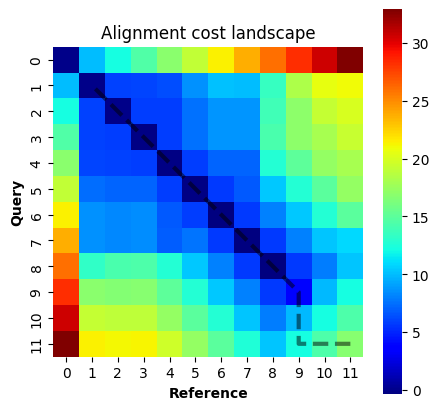

In [10]:
marker_gene_list = ["Pdx1", "Gcg"]
marker_gene = "Pdx1"
gene_obj = aligner.results_map[marker_gene] # driver gene example
alignment_str = gene_obj.alignment_str
print(alignment_str)
print(g2g.VisualUtils.color_al_str(alignment_str)) 

print("=====================")
print(gene_obj.al_visual)

print("=====================")
# Alignment landscape of costs (Note: dashed black path is the optimal alignment)
gene_obj.landscape_obj.plot_alignment_landscape()
# Note: optimal path diagonals represent matches; 
# vertical and horizontal paths could represent either warp matches or indels (mismatches)

MMMMMMMMMIIDD
Optimal alignment cost: 16.75 nits
Alignment similarity percentage: 69.23 %


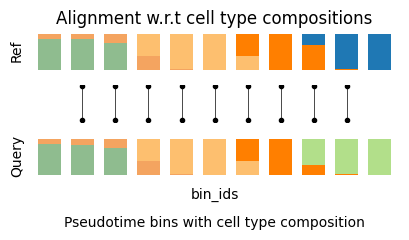

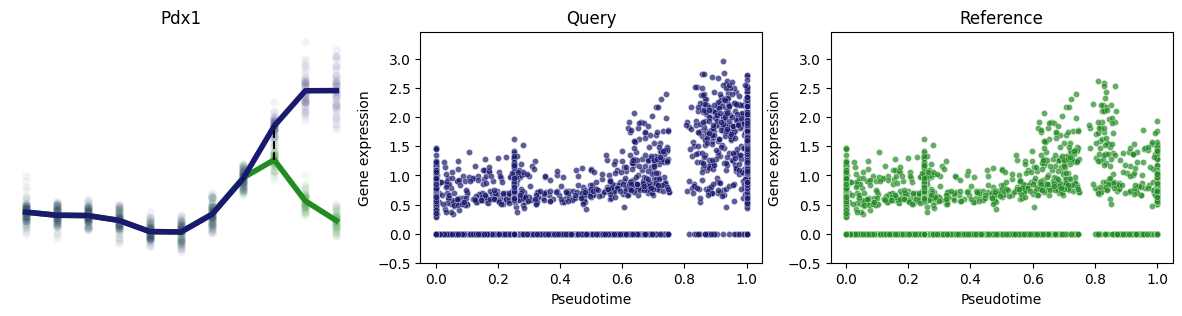

In [11]:
g2g.VisualUtils.show_gene_alignment(marker_gene, aligner, adata_ref, adata_query, annotation_colname, joint_cmap)

### 横跨对齐基因来聚合细胞级别的对齐

Average Alignment:  MMMMMMMMMMM (cell-level)
% similarity: 100.0


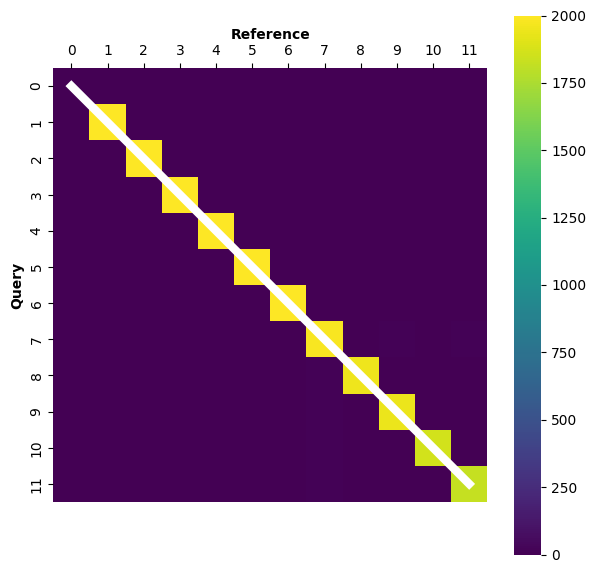

In [12]:
aligner.get_aggregate_alignment() 
# Note: White path represents the average alignment path where diagonals represent matches; 
# vertical and horizontal paths could represent either warp matches or indels (mismatches)

## 3. 分析基因级别的对齐

Mean alignment similarity percentage (matched %): 
97.33000000000001 %


,Gene,alignment_similarity_percentage,opt_alignment_cost,l2fc,color,abs_l2fc
1317,Acot7,0.375,26.260866,0.063006,red,0.063006
1719,Plk1,0.375,26.253662,0.018648,red,0.018648
1652,Prss53,0.4667,21.520185,-1.740761,red,1.740761
422,Serpina1b,0.4667,21.570898,0.530779,red,0.530779
372,Rprml,0.4667,21.216277,-0.305961,red,0.305961
...,...,...,...,...,...,...
1900,Gata1,1.0,-1.007792,NaN,green,NaN
1925,Gm9112,1.0,-1.007792,NaN,green,NaN
1971,Gm26617,1.0,-1.007792,NaN,green,NaN
1973,Dmrtc1b,1.0,-1.007792,NaN,green,NaN


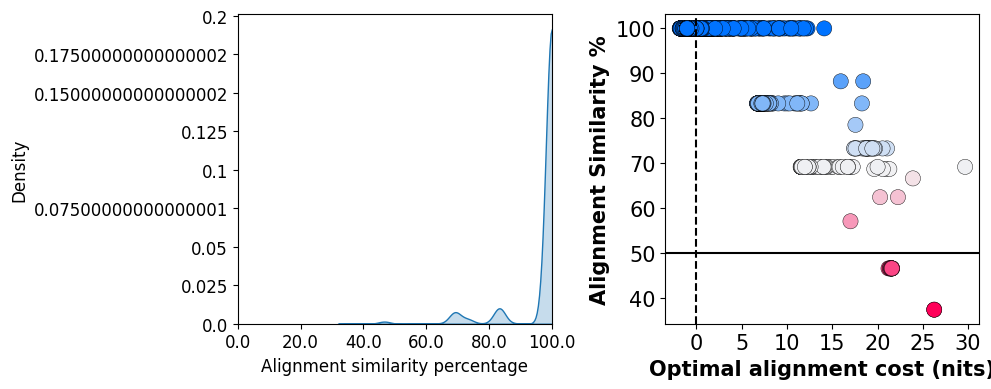

In [13]:
df = aligner.get_stat_df() # ordered genes according to alignment similarity statistics 
df

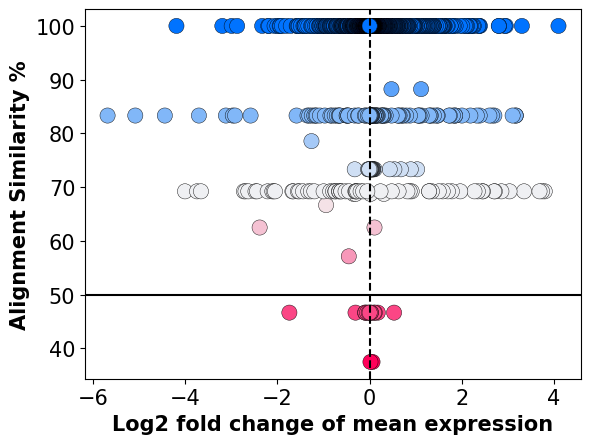

In [14]:
g2g.VisualUtils.plot_alignmentSim_vs_l2fc(df)

In [15]:
earliest_match_sorted_genes_list = aligner.show_ordered_alignments() 

In the order of the first match occurrence along pseudotime
Gene           Alignment
-------------  -----------------
Rgs20          MMMMMMMMMMM
Sbspon         MMMMMMMMMMM
Mcm3           MMMMMMMMMMM
Neurl3         MMMMMMMMMMM
Fhl2           MMMMMMMMMMM
Gm17767        MMMMMMMMMMM
Ankrd44        MMMMMMMMMMM
Gm4208         MMMMMMMMMMM
Klf7           MMMMMMMMMMM
Akr1cl         MMMMMMMMMMM
Gm10558        MMMMMMMMMMM
Myl1           MMMMMMMMMMM
Gm4319         MMMMMMMMMMM
Mreg           MMMMMMMMMMM
Igfbp5         MMMMMMMMMMM
C530043A13Rik  MMMMMMMMMMM
Tmbim1         MMMMMMMMMMM
Fev            MMMMMMMMMMM
Cryba2         MMMMMMMMMMM
Ihh            MMMMMMMMMMM
Ptprn          MMMMMMMMMMM
Resp18         MMMMMMMMMMM
5730419F03Rik  MMMMMMMMMMM
Scg2           MMMMMMMMMMM
Sphkap         MMMMMMMMMMM
Pid1           MMMMMMMMMMM
Dner           MMMMMMMMMMM
Nmur1          MMMMMMMMMMM
Iqca           MMMMMMMMMMM
Hes6           MMMMMMMMMMM
Kif1a          MMMMMMMMMMM
Pdcd1          MMMMMMMMMMM
Pam            MMM

不相关基因的基因集突出性的分析

In [16]:
threshold_similarity = 0.5
topDEgenes = df[list(df['alignment_similarity_percentage'] <=threshold_similarity)]['Gene']
# Calling wrapper function for GSEAPy enrichr inferface
pathway_df = g2g.PathwayAnalyser.run_overrepresentation_analysis(topDEgenes) 
pathway_df.head(5)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes


## 聚类对齐结果

运行实验以确定分层聚类中对齐聚类的距离阈值。我们的目标是选择一个局部最优阈值，在高平均轮廓分数和低数量的具有生物学意义的聚类之间进行良好的权衡

Compute distance matrix
- using levenshtein distance metric
Experimental mode: exploring different thresholds


 55%|█████▍    | 54/99 [00:22<00:18,  2.43it/s]


-- Cluster diagnostic plots
Potential candidates for distance threshold: a locally optimal thresholds that gives a good trade-off between high mean Silhouette score and low number of clusters 


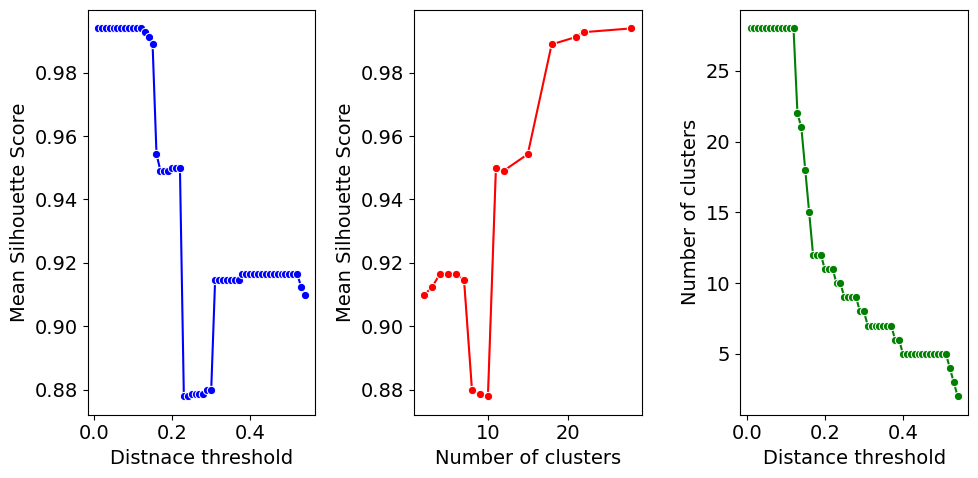

In [17]:
df = g2g.ClusterUtils.run_clustering(aligner, metric='levenshtein', experiment_mode=True) 

In [18]:
g2g.ClusterUtils.run_clustering(aligner, metric='levenshtein', DIST_THRESHOLD=0.37) 

Compute distance matrix
- using levenshtein distance metric
run agglomerative clustering | distance threshold = 0.37
silhouette_score:  0.9145689978202788


Cluster ID | Number of genes in the cluster


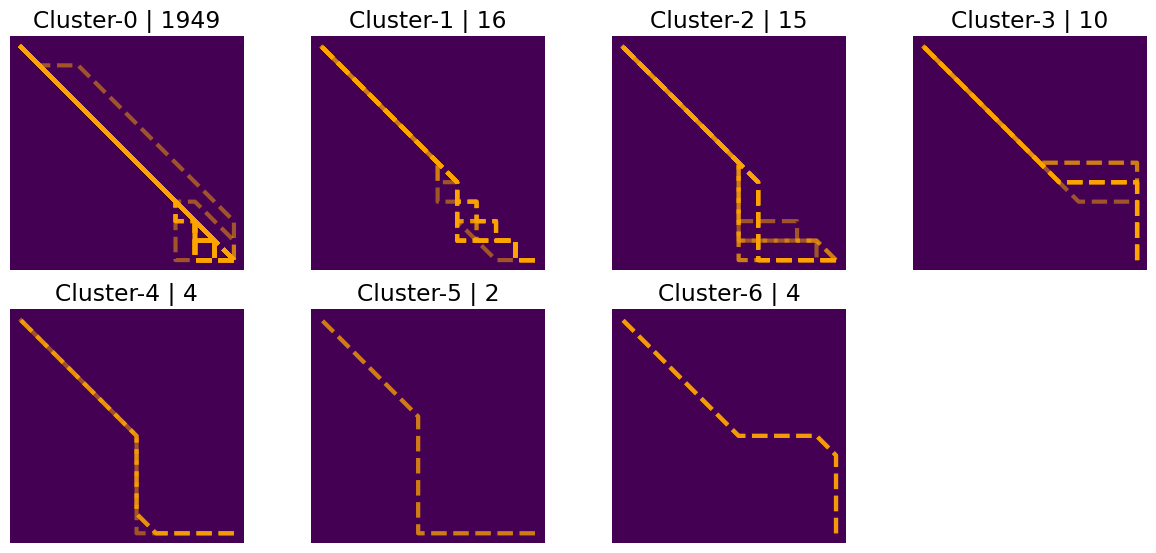

In [19]:
g2g.ClusterUtils.visualise_clusters(aligner,n_cols = 4, figsize= (10,6))

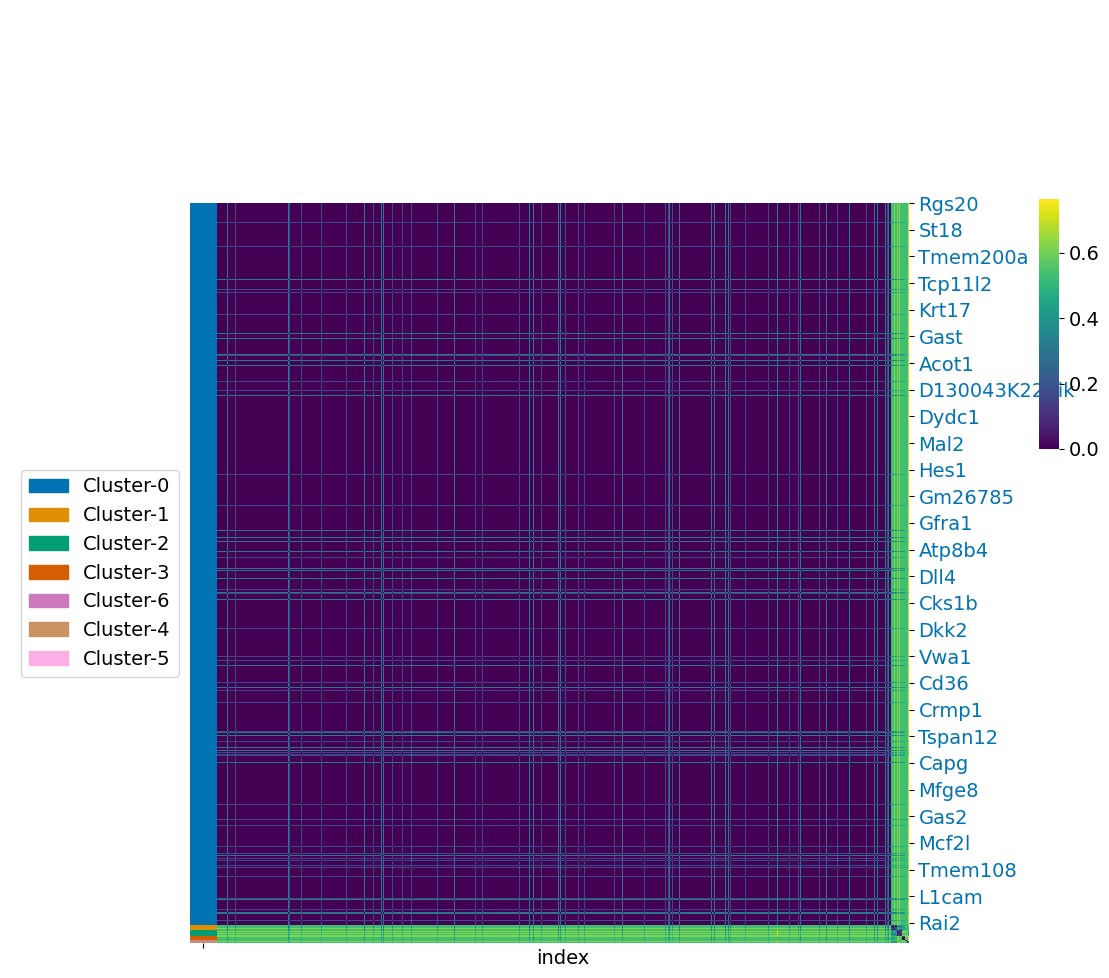

In [20]:
g2g.VisualUtils.plot_distmap_with_clusters(aligner)

In [21]:
g2g.ClusterUtils.print_cluster_average_alignments(aligner)

cluster:  0 MMMMMMMMMMM ( 1949 genes)
cluster:  1 MMMMMMMIIIIDDDD ( 16 genes)
cluster:  2 MMMMMMMIVVVDDDD ( 15 genes)
cluster:  3 MMMMMMMDWWWIIII ( 10 genes)
cluster:  4 MMMMMMIIIIDDMWW ( 4 genes)
cluster:  5 MMMMMMVVVVDDDMW ( 2 genes)
cluster:  6 MMMMMMIVDDDDMVV ( 4 genes)


In [22]:
# To access the genes in a particular cluster
cluster_id = 1
print(aligner.gene_clusters[cluster_id]) 

# To print all gene alignments in the cluster
aligner.show_cluster_alignment_strings(cluster_id)

['Olfml2b', 'Trim47', 'Rprml', 'Serpina1b', 'Lgi3', 'Trp53cor1', 'Tff2', 'Sema6b', 'Gcg', 'Kcnq4', 'Acot7', 'Nphp4', 'Prss53', 'Prss8', 'Plk1', 'Nfix']
MMMMMMMIIIDDDID
MMMMMMMIDIDIDID
MMMMMMMIIDDIDID
MMMMMMMIIIDDDID
MMMMMMMIIIDDDID
MMMMMMMIIIDDDID
MMMMMMMIIIDDDID
MMMMMMMIIDDIDID
MMMMMMMIIMMDD
MMMMMMMIDIIDDID
MMMMMMIIDDIDIDID
MMMMMMMIDIIDDID
MMMMMMMIIIDDDID
MMMMMMMIIDDIDID
MMMMMMIDIDIDIDID
MMMMMMMIIIDDDID


### 给定基因集的平均比对结果

Average Alignment:  MMMMMMMMMMM (cell-level)


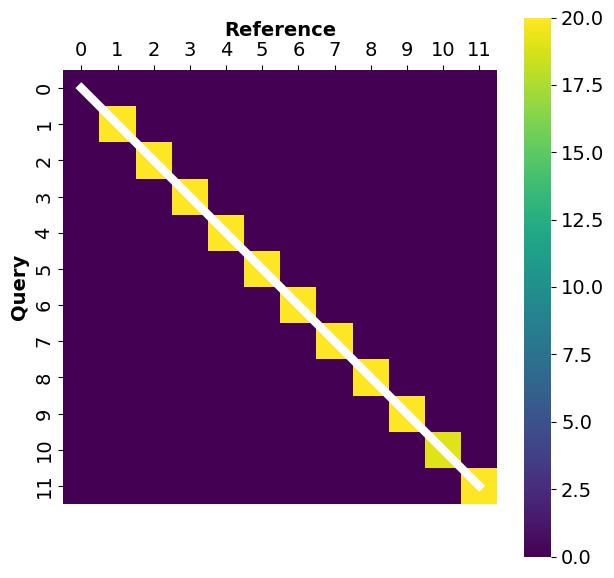

In [23]:
GENE_SUBSET = gene_list[40:60]
aligner.get_aggregate_alignment_for_subset(GENE_SUBSET)

### 探索给定基因集合的对齐和趋势

In [24]:
IGS = g2g.PathwayAnalyser.InterestingGeneSets(gene_list) 

Initialising to use KEGG_2021_Human and MSigDB_Hallmark_2020 only


In [25]:
IGS.add_new_set_from_msigdb('MSigDB_Hallmark_2020', 'Epithelial Mesenchymal Transition', user_setname='EMT') 

In [26]:
g2g.PathwayAnalyser.get_pathway_alignment_stat(aligner, IGS.SETS['EMT'], 'EMT', cluster=True, FIGSIZE=(3,6))

Gene set: =======  EMT
mean matched percentage:  nan %


ZeroDivisionError: division by zero

In [ ]:
g2g = PathwayAnalyser.get_pathway_alignment_stat(aligner, gene_list[0:20], 'EMT', cluster=True, FIGSIZE=(3,6))

NameError: name 'PathwayAnalyser' is not defined